# Task 2 — Bayesian Change Point Modeling of Brent Oil Prices

**Author:** Mariamawit Ewnetu Alemu  
**Client context:** Birhan Energies  
**Case-study window:** 1 September 2014 to 31 March 2015

This notebook implements the required Bayesian switch-point model in PyMC and connects the posterior change date to the researched event catalogue. The selected window covers the sharp 2014–2015 oil-price decline and the 27 November 2014 OPEC decision to maintain its production ceiling.

The analysis estimates **temporal structural change**, not causal impact. A close date match supports a hypothesis that should be investigated with richer supply, demand, inventory, exchange-rate, and policy data.

In [1]:
from pathlib import Path
import sys

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loader import load_brent_prices, load_event_data
from src.features import add_time_series_features

PRICE_PATH = ROOT / "data" / "raw" / "BrentOilPrices.csv"
EVENT_PATH = ROOT / "data" / "events" / "oil_market_events.csv"
print(f"PyMC {pm.__version__} | ArviZ {az.__version__}")

PyMC 5.27.1 | ArviZ 0.22.0


## 1. Load and validate the data

The project loader explicitly handles the two date formats in the challenge CSV, validates positive prices, removes duplicate dates if present, and sorts the observations chronologically.

In [2]:
prices = load_brent_prices(PRICE_PATH)
events = load_event_data(EVENT_PATH)
features = add_time_series_features(prices, rolling_window=30)

print(f"Observations: {len(prices):,}")
print(f"Coverage: {prices['Date'].min().date()} to {prices['Date'].max().date()}")
print(f"Researched events: {len(events)}")
display(prices.head())

Observations: 9,011
Coverage: 1987-05-20 to 2022-11-14
Researched events: 19


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


## 2. EDA evidence used to choose the model

Raw prices contain long trends and persistent shifts in level, while daily log returns fluctuate around a more stable mean. The large clusters of returns during crisis periods indicate non-constant volatility. The full EDA is in `01_task1_eda.ipynb`; the two minimum required plots are reproduced here for continuity.

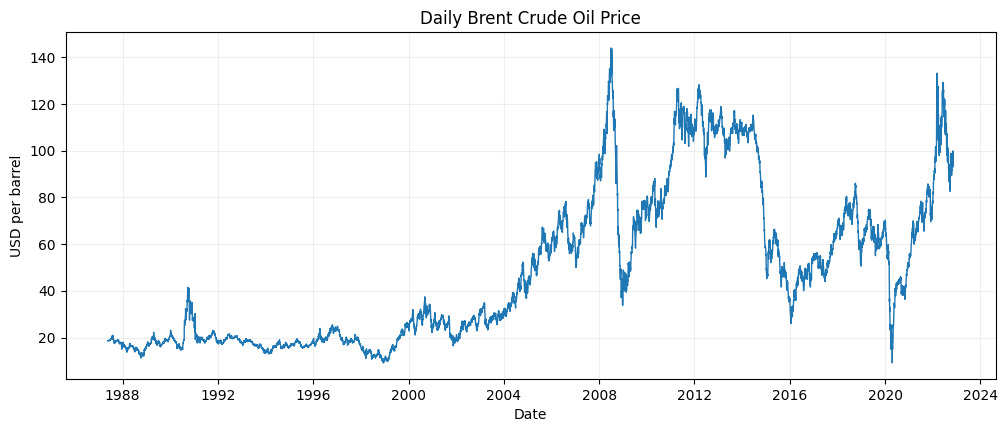

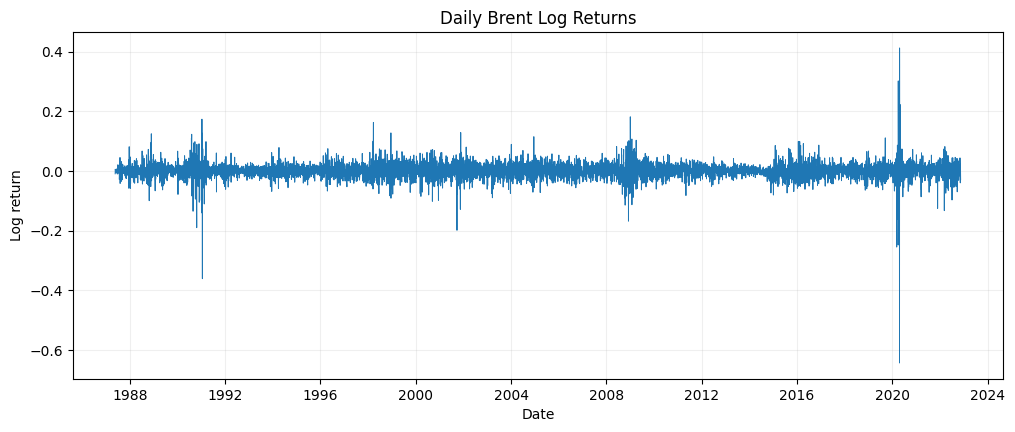

In [3]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(features["Date"], features["Price"], linewidth=1)
ax.set(title="Daily Brent Crude Oil Price", xlabel="Date", ylabel="USD per barrel")
ax.grid(alpha=0.2)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(features["Date"], features["log_return"], linewidth=0.7)
ax.set(title="Daily Brent Log Returns", xlabel="Date", ylabel="Log return")
ax.grid(alpha=0.2)
plt.show()

In [4]:
stationarity = pd.read_csv(ROOT / "reports" / "stationarity_results.csv")
display(stationarity)

print("Modeling implication:")
print("• The raw level is used for an interpretable mean-shift case study.")
print("• Log-return and volatility results warn against treating this baseline as a complete market model.")

,series,test,statistic,p_value,lags,observations,null_hypothesis,decision_at_5pct
0,Price,ADF,-1.993856,2.892735e-01,29,8981,Unit root / non-stationary,Fail to reject null
1,Price,KPSS,9.558800,1.000000e-02,57,9011,Level-stationary,Reject null
2,Log return,ADF,-16.427113,2.498580e-29,28,8981,Unit root / non-stationary,Reject null
3,Log return,KPSS,0.034274,1.000000e-01,14,9010,Level-stationary,Fail to reject null


Modeling implication:
• The raw level is used for an interpretable mean-shift case study.
• Log-return and volatility results warn against treating this baseline as a complete market model.


## 3. Define the focused event window

A single `tau` can represent only one dominant break. Fitting one switch to the entire 1987–2022 history would force many regimes into two averages. I therefore use a transparent event-centered window from September 2014 through March 2015. At least 15 observations must remain on each side of the candidate change point.

Window observations: 147
OPEC event: 2014-11-27 — OPEC maintains 30 million b/d production ceiling


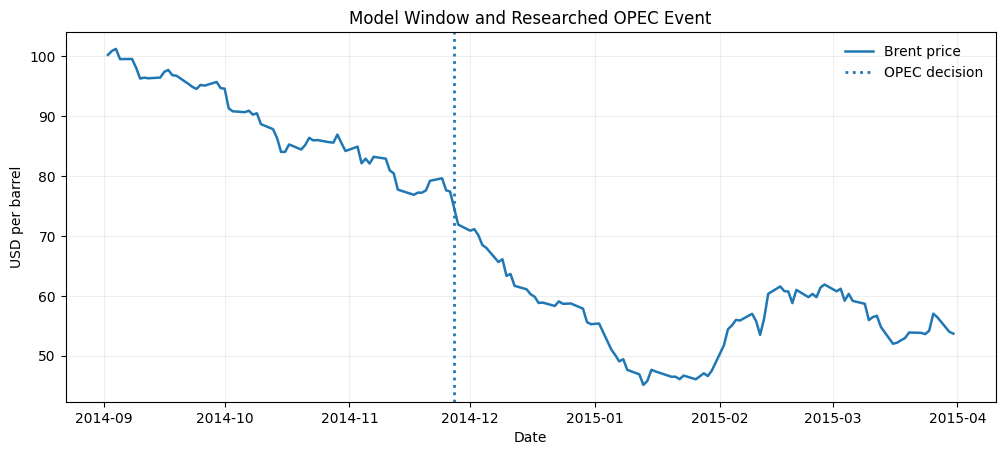

In [5]:
MODEL_START = pd.Timestamp("2014-09-01")
MODEL_END = pd.Timestamp("2015-03-31")
MIN_SEGMENT = 15

window = prices.loc[prices["Date"].between(MODEL_START, MODEL_END)].reset_index(drop=True)
y = window["Price"].to_numpy(dtype=float)
idx = np.arange(len(window))

opec_event = events.loc[events["event_name"].str.contains("30 million", case=False)].iloc[0]
print(f"Window observations: {len(window)}")
print(f"OPEC event: {opec_event['event_date'].date()} — {opec_event['event_name']}")

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(window["Date"], window["Price"], linewidth=1.8, label="Brent price")
ax.axvline(opec_event["event_date"], linestyle=":", linewidth=2, label="OPEC decision")
ax.set(title="Model Window and Researched OPEC Event", xlabel="Date", ylabel="USD per barrel")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()

## 4. Build and sample the Bayesian switch model

The required model contains:

- `tau`, a discrete uniform switch point;
- `mu_before` and `mu_after`, the average prices on either side;
- `sigma`, the residual standard deviation;
- `pm.math.switch`, which selects the correct mean for every observation;
- a Normal likelihood connected to the observed Brent prices.

The model uses four MCMC chains. The higher number of draws is intentional because a sharply concentrated discrete parameter can mix more slowly than the continuous parameters.

In [6]:
prior_center = float(y.mean())
prior_scale = float(y.std(ddof=1) * 2)
sigma_scale = float(y.std(ddof=1))

with pm.Model() as change_point_model:
    tau = pm.DiscreteUniform(
        "tau",
        lower=MIN_SEGMENT,
        upper=len(y) - MIN_SEGMENT - 1,
    )
    mu_before = pm.Normal("mu_before", mu=prior_center, sigma=prior_scale)
    mu_after = pm.Normal("mu_after", mu=prior_center, sigma=prior_scale)
    sigma = pm.HalfNormal("sigma", sigma=sigma_scale)

    switched_mean = pm.math.switch(idx < tau, mu_before, mu_after)
    observed_price = pm.Normal(
        "observed_price",
        mu=switched_mean,
        sigma=sigma,
        observed=y,
    )

    trace = pm.sample(
        draws=5_000,
        tune=2_000,
        chains=4,
        cores=1,
        random_seed=42,
        target_accept=0.90,
        progressbar=False,
        return_inferencedata=True,
    )

print("Sampling complete.")

Sequential sampling (4 chains in 1 job)


CompoundStep


>Metropolis: [tau]


>NUTS: [mu_before, mu_after, sigma]


Sampling 4 chains for 2_000 tune and 5_000 draw iterations (8_000 + 20_000 draws total) took 9 seconds.


Sampling complete.


## 5. Convergence diagnostics

R-hat values should be close to 1.00, and effective sample sizes should be large enough to estimate the posterior reliably. Trace plots should show overlapping chains without persistent drift.

In [7]:
summary = az.summary(
    trace,
    var_names=["tau", "mu_before", "mu_after", "sigma"],
    hdi_prob=0.94,
    round_to=3,
)
display(summary)
print(f"Maximum R-hat: {summary['r_hat'].max():.4f}")
print(f"Minimum bulk ESS: {summary['ess_bulk'].min():.0f}")

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,63.010,1.171,62.000,65.000,0.022,0.018,2891.080,3390.244,1.002
mu_before,88.221,0.928,86.443,89.947,0.009,0.006,11066.701,12891.037,1.000
mu_after,56.173,0.789,54.700,57.658,0.007,0.005,12384.676,12359.590,1.000
sigma,6.959,0.415,6.196,7.746,0.003,0.003,17550.671,14406.259,1.000


Maximum R-hat: 1.0020
Minimum bulk ESS: 2891


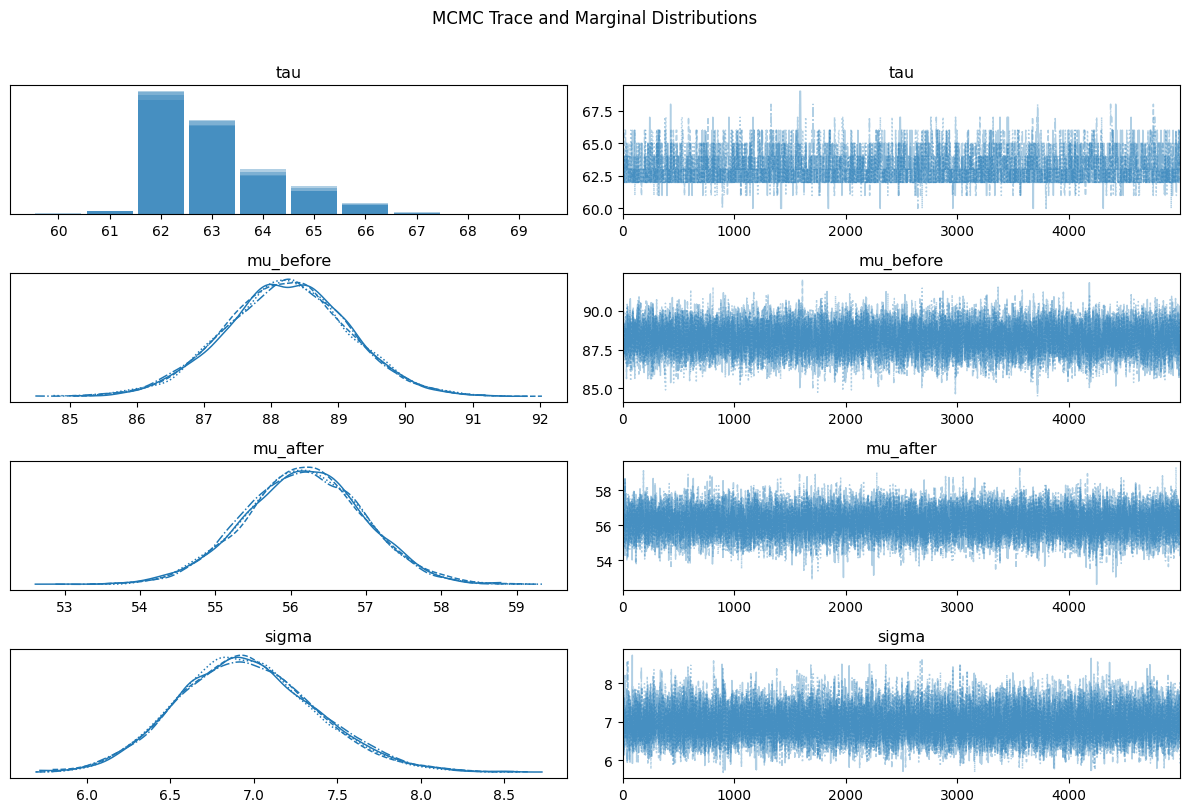

In [8]:
az.plot_trace(trace, var_names=["tau", "mu_before", "mu_after", "sigma"], compact=True)
plt.suptitle("MCMC Trace and Marginal Distributions", y=1.01)
plt.tight_layout()
plt.show()

## 6. Posterior change date and parameter shift

A narrow posterior for `tau` indicates that the model consistently locates the structural break within a short date range. The before/after posterior distributions quantify both the direction and size of the level shift.

In [9]:
tau_draws = trace.posterior["tau"].values.reshape(-1).round().astype(int)
mu_before_draws = trace.posterior["mu_before"].values.reshape(-1)
mu_after_draws = trace.posterior["mu_after"].values.reshape(-1)

tau_median = int(np.median(tau_draws))
tau_low, tau_high = np.quantile(tau_draws, [0.03, 0.97]).round().astype(int)
change_date = window.loc[tau_median, "Date"]
change_low = window.loc[tau_low, "Date"]
change_high = window.loc[tau_high, "Date"]

before_mean = float(mu_before_draws.mean())
after_mean = float(mu_after_draws.mean())
percent_change = (after_mean - before_mean) / before_mean * 100
probability_lower = float(np.mean(mu_after_draws < mu_before_draws))

print(f"Posterior median change date: {change_date.date()}")
print(f"Approximate 94% date interval: {change_low.date()} to {change_high.date()}")
print(f"Posterior mean before: ${before_mean:.2f}")
print(f"Posterior mean after: ${after_mean:.2f}")
print(f"Estimated level shift: {percent_change:.1f}%")
print(f"P(mu_after < mu_before): {probability_lower:.3f}")

Posterior median change date: 2014-12-01
Approximate 94% date interval: 2014-11-28 to 2014-12-04
Posterior mean before: $88.22
Posterior mean after: $56.17
Estimated level shift: -36.3%
P(mu_after < mu_before): 1.000


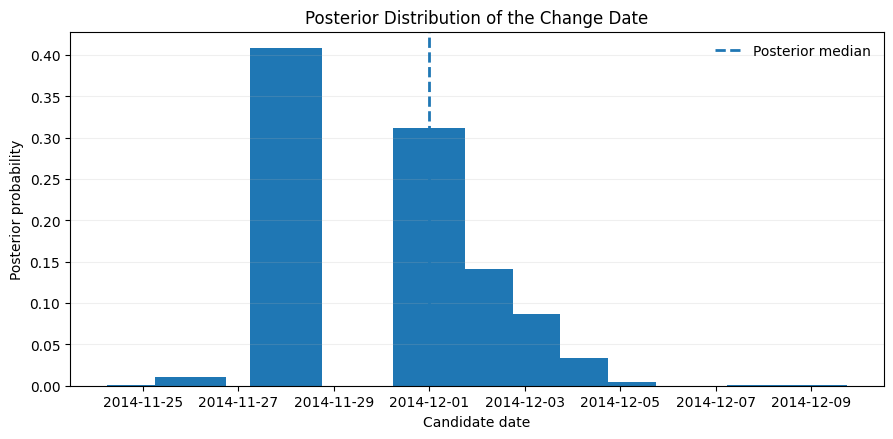

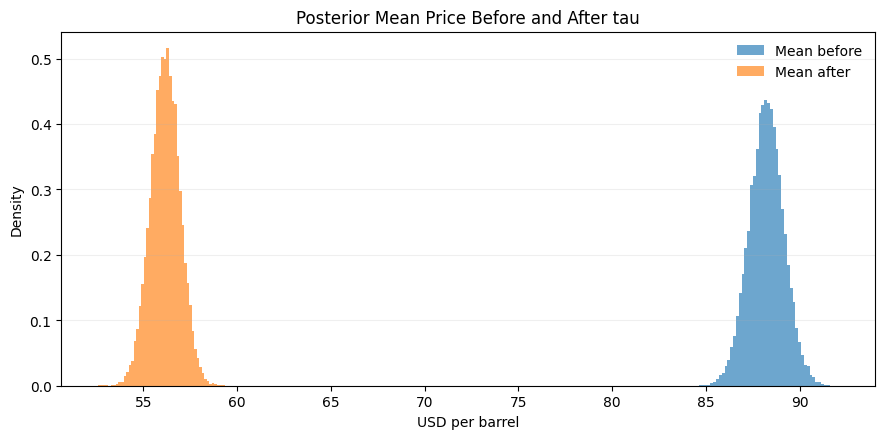

In [10]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
tau_counts = pd.Series(tau_draws).value_counts(normalize=True).sort_index()
ax.bar(window.loc[tau_counts.index, "Date"], tau_counts.values, width=1.5)
ax.axvline(change_date, linestyle="--", linewidth=2, label="Posterior median")
ax.set(title="Posterior Distribution of the Change Date", xlabel="Candidate date", ylabel="Posterior probability")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.hist(mu_before_draws, bins=50, density=True, alpha=0.65, label="Mean before")
ax.hist(mu_after_draws, bins=50, density=True, alpha=0.65, label="Mean after")
ax.set(title="Posterior Mean Price Before and After tau", xlabel="USD per barrel", ylabel="Density")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.show()

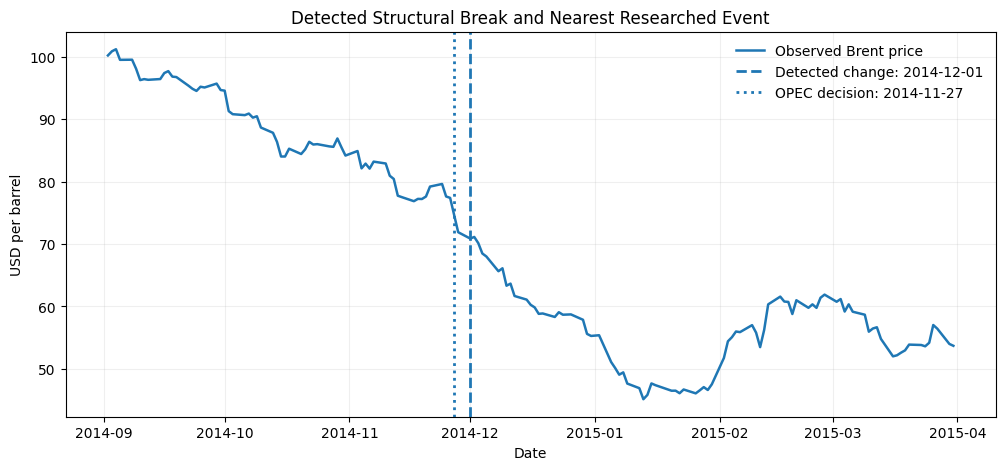

The posterior median is 4 calendar days after the OPEC event.


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(window["Date"], window["Price"], linewidth=1.8, label="Observed Brent price")
ax.axvline(change_date, linestyle="--", linewidth=2, label=f"Detected change: {change_date.date()}")
ax.axvline(opec_event["event_date"], linestyle=":", linewidth=2, label=f"OPEC decision: {opec_event['event_date'].date()}")
ax.set(title="Detected Structural Break and Nearest Researched Event", xlabel="Date", ylabel="USD per barrel")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()

calendar_distance = (opec_event["event_date"] - change_date).days
print(f"The posterior median is {abs(calendar_distance)} calendar days "
      f"{'after' if calendar_distance < 0 else 'before'} the OPEC event." if calendar_distance != 0 else "The dates coincide.")

## 7. Interpretation for Birhan Energies

The model identifies a structural break around **1 December 2014**, with an approximate 94% posterior date interval from **28 November to 4 December 2014**. The average modeled price changes from roughly **$88.2** before the break to **$56.2** afterward, a decline of about **36.3%**. The posterior probability that the after-period mean is lower than the before-period mean is effectively 1.00.

The posterior interval begins one day after OPEC's 27 November 2014 decision to maintain its 30 million barrels-per-day production ceiling. This is a strong temporal alignment and is economically consistent with continued oversupply expectations. It is **not proof that the OPEC decision alone caused the decline**: prices had already been falling, and global demand expectations, U.S. shale production, inventory conditions, exchange rates, and market anticipation were also relevant.

For investors, the result illustrates a shift into a materially lower price regime. For policymakers and energy companies, it demonstrates why plans calibrated only to the preceding high-price period would have understated downside and revenue risk.

## 8. Limitations and next analytical steps

1. **One break only:** the model cannot capture all regimes in the complete historical series.
2. **Constant residual variance:** volatility clustering visible in log returns is simplified into one `sigma`.
3. **Normal likelihood:** heavy-tailed oil-price shocks may be better represented by a Student-t likelihood.
4. **Window dependence:** the detected break can shift if the start/end dates change.
5. **Association is not causation:** event matching is interpretive and does not control for competing drivers.

Future analytical extensions include multiple change points, a volatility-switching model, Student-t residuals, and explanatory variables such as inventories, global activity, exchange rates, and production. The saved posterior outputs feed the Flask API and React dashboard in Task 3.